# ANALIZA PODATKOV O KNJIGAH

Analiza temelji na podatkih s spletne strani dobreknjige.si, in sicer na naboru knjig, ki jih ima v svoji zbirki Mestna knjižnica Ljubljana. Podatki vsebujejo naslov, avtorja, oceno, število ocen, obseg (število strani), oceno časa branja in podatek o tem, ali je bila knjiga kdaj nagrajena.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_rows", 20)

%matplotlib inline

KNJIGE = pd.read_csv("podatki/knjige.csv", index_col="id")
KNJIGE

,avtor,ocena,stevilo_ocen,stevilo_strani,cas_branja,nagrajena,naslov,url
id,,,,,,,,
kjer-tece-kosuta,Maja B. Kranjc,4.3,4,245.0,8-9 ur,True,Kjer teče košuta,https://www.dobreknjige.si/knjige/kjer-tece-ko...
revolveras,Stephen King,0.0,0,267.0,8-9 ur,False,Revolveraš,https://www.dobreknjige.si/knjige/revolveras/
zadnja-vecerja-likovne-krimi-kratke-zgodbe,Avgust Demšar,4.5,2,279.0,9-10 ur,False,Zadnja večerja : likovne krimi kratke zgodbe,https://www.dobreknjige.si/knjige/zadnja-vecer...
v-zadnjem-trenutku-zgodbe-o-zenskah-in-moskih,Claire Keegan,5.0,4,78.0,2-3 ur,False,V zadnjem trenutku : zgodbe o ženskah in moških,https://www.dobreknjige.si/knjige/v-zadnjem-tr...
optimisti-roman,Vid Simoniti,0.0,0,477.0,15-16 ur,False,Optimisti: roman,https://www.dobreknjige.si/knjige/optimisti-ro...
...,...,...,...,...,...,...,...,...
slepi-maser,Catalin Dorian Florescu,4.3,3,279.0,9-10 ur,False,Slepi maser,https://www.dobreknjige.si/knjige/slepi-maser/
v-kozi-drugega,Neil Jordan,4.4,5,372.0,12-13 ur,False,V koži drugega,https://www.dobreknjige.si/knjige/v-kozi-drugega/
rezervno-zivljenje,Lidija Dimkovska,4.3,6,429.0,14-15 ur,True,Rezervno življenje,https://www.dobreknjige.si/knjige/rezervno-ziv...


## Priprava podatkov

`cas_branja` je v podatkih zapisan kot besedilni razpon (npr. "8-9 ur"), zato ga pretvorimo v številsko povprečje razpona, da ga lahko uporabimo za izračune in grafe.

Prav tako velja opozoriti: `ocena` je pri knjigah, ki še nimajo nobene ocene (`stevilo_ocen == 0`), zapisana kot 0.0 - to NI dejanska ocena "0", ampak pomeni "še ni ocenjeno". Za vse izračune povprečnih ocen zato uporabljamo samo podmnožico knjig, ki imajo vsaj eno oceno.

In [34]:
def povprecni_cas(vrednost):
    """Pretvori niz oblike '8-9 ur' ali '1 ur' v številsko povprečje (v urah)."""
    if pd.isna(vrednost) or vrednost == "":
        return None
    stevilke = [int(s) for s in re.findall(r"\d+", str(vrednost))]
    return sum(stevilke) / len(stevilke) if stevilke else None

KNJIGE["cas_branja_ur"] = KNJIGE["cas_branja"].apply(povprecni_cas)

# Podmnozica knjig, ki imajo vsaj eno oceno - uporabljena za vse analize ocen
OCENJENE = KNJIGE[KNJIGE["stevilo_ocen"] > 0]

print(f"Skupno knjig: {len(KNJIGE)}")
print(f"Knjig z vsaj eno oceno: {len(OCENJENE)}")

Skupno knjig: 991
Knjig z vsaj eno oceno: 821


In [35]:
manjkajoce_vrednosti = KNJIGE.isna().sum()
manjkajoce_vrednosti

avtor              4
ocena              0
stevilo_ocen       0
stevilo_strani    32
cas_branja        32
nagrajena          0
naslov             0
url                0
cas_branja_ur     32
dtype: int64

## Analiza ocen

Porazdelitev ocen med vsemi ocenjenimi knjigami:

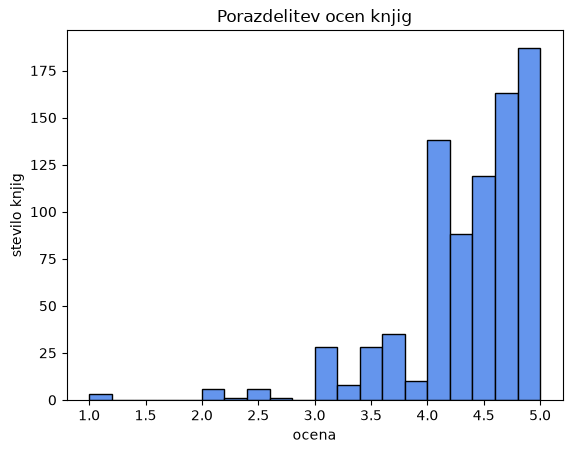

In [36]:
ax = OCENJENE["ocena"].plot.hist(bins=20, color="cornflowerblue", edgecolor="black")
ax.set_xlabel("ocena")
ax.set_ylabel("stevilo knjig")
ax.set_title("Porazdelitev ocen knjig");

NAJBOLJE OCENJENE KNJIGE (upoštevamo samo tiste z vsaj 3 ocenami, da izločimo naključne visoke ocene z zelo malo glasovi):

In [37]:
zanesljive_ocene = OCENJENE[OCENJENE["stevilo_ocen"] >= 3]

top10_najbolje = zanesljive_ocene[["naslov", "avtor", "ocena", "stevilo_ocen"]].sort_values(
    ["ocena", "stevilo_ocen"], ascending=[False, False]
).head(10)
top10_najbolje

,naslov,avtor,ocena,stevilo_ocen
id,,,,
umetnina,Umetnina,Émile Zola,5.0,9
cez-potok-ne-cez-most,"Čez potok, ne čez most",Linn Skåber,5.0,7
kremeljski-mag,Kremeljski mag,Giuliano Da Empoli,5.0,6
hci-iz-prihodnosti,Hči iz prihodnosti,Diane Chamberlain,5.0,6
jezero,Jezero,Bianca Bellová,5.0,6
zamaknjenost-lol-v-stein,Zamaknjenost Lol V. Stein,Marguerite Duras,5.0,6
simonove-price,Simonove priče,Rudi Podržaj,5.0,6
prevec-zvezd,Preveč zvezd,Mateja Gomboc,5.0,5
lagum,Lagum,Svetlana Velmar-Janković,5.0,5


NAJSLABŠE OCENJENE KNJIGE (enak pogoj, vsaj 3 ocene):

In [38]:
top10_najslabse = zanesljive_ocene[["naslov", "avtor", "ocena", "stevilo_ocen"]].sort_values(
    ["ocena", "stevilo_ocen"], ascending=[True, False]
).head(10)
top10_najslabse

,naslov,avtor,ocena,stevilo_ocen
id,,,,
cas-ladij,Čas ladij,Renata Picej,2.3,4
satanov-tango,Satanov tango,László Krasznahorkai,2.5,4
zajec-in-pol,Zajec in pol,Manuel Manzano,2.7,3
nadlezna-ljubezen,Nadležna ljubezen,Elena Ferrante,3.0,16
play-boy,Play boy,Constance Debré,3.0,3
ena-sama-dobra-stvar,Ena sama dobra stvar,Alexandra Potter,3.3,6
vse-to-smo-videli,Vse to smo videli,Hanna Bervoets,3.3,4
kako-sem-spoznal-violet-park,Kako sem spoznal Violet Park,Jenny Valentine,3.3,4
samec,Samec,Christopher Isherwood,3.3,3


## Analiza obsega knjig

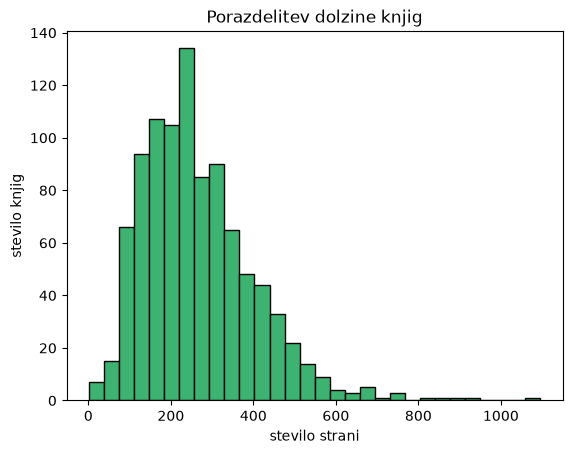

In [39]:
ax = KNJIGE["stevilo_strani"].dropna().plot.hist(bins=30, color="mediumseagreen", edgecolor="black")
ax.set_xlabel("stevilo strani")
ax.set_ylabel("stevilo knjig")
ax.set_title("Porazdelitev dolzine knjig");

NAJDALJŠE KNJIGE:

In [40]:
top10_najdaljse = KNJIGE[["naslov", "avtor", "stevilo_strani"]].sort_values("stevilo_strani", ascending=False).head(10)
top10_najdaljse

,naslov,avtor,stevilo_strani
id,,,
osmo-zivljenje-za-brilko,Osmo življenje : (za Brilko),Nino Haratišvili,1095.0
skriti-grob,Skriti grob,J. K. Rowling,934.0
nemirna-kri,Nemirna kri,J. K. Rowling,903.0
zalost-belgije,Žalost Belgije,Hugo Claus,853.0
druga-preteklost,Druga preteklost,Vinko Möderndorfer,824.0
moby-dick-ali-kit,Moby Dick ali Kit,Herman Melville,767.0
wolf-hall,Wolf Hall,Hilary Mantel,735.0
razvejenje,Razvejenje,Richard Powers,735.0
sophiejina-odlocitev,Sophiejina odločitev,William Styron,729.0


NAJKRAJŠE KNJIGE:

In [41]:
top10_najkrajse = KNJIGE[["naslov", "avtor", "stevilo_strani"]].dropna(subset=["stevilo_strani"]).sort_values("stevilo_strani", ascending=True).head(10)
top10_najkrajse

,naslov,avtor,stevilo_strani
id,,,
mag,Mag,John Fowles,2.0
v-vrtincu-crk-o-deklici-s-skotopicnim-sindromom-ali-sindrom-helen-irlen,V vrtincu črk: o deklici s skotopičnim sindrom...,Aksinja Kermauner,14.0
za-tiste-ki-hocejo-leteti,"Za tiste, ki hočejo leteti",Pirkko Vainio,23.0
sosedje-in-prijatelji,Sosedje in prijatelji,Lawrence Schimel,31.0
odvratne-rime,Odvratne rime,Roald Dahl,32.0
kaj-storis-z-idejo,Kaj storiš z idejo?,Kobi Yamada,34.0
zebra-v-ogledalu,Zebra v ogledalu,Tina Arnuš Pupis,36.0
vsi-moramo-biti-feministi,Vsi moramo biti feministi,Chimamanda Ngozi Adichie,46.0
umetnina,Umetnina,Émile Zola,56.0


## Nagrade

Delež knjig v zbirki, ki so bile kdaj nagrajene, in primerjava povprečne ocene med nagrajenimi in nenagrajenimi knjigami.

In [42]:
delez_nagrajenih = KNJIGE["nagrajena"].mean() * 100
print(f"Delez nagrajenih knjig: {delez_nagrajenih:.1f} %")
print(f"Stevilo nagrajenih knjig: {KNJIGE['nagrajena'].sum()} od {len(KNJIGE)}")

Delez nagrajenih knjig: 14.1 %
Stevilo nagrajenih knjig: 140 od 991


In [43]:
primerjava_nagrad = OCENJENE.groupby("nagrajena")["ocena"].agg(["mean", "count"]).round(2)
primerjava_nagrad

,mean,count
nagrajena,,
False,4.37,696
True,4.29,125


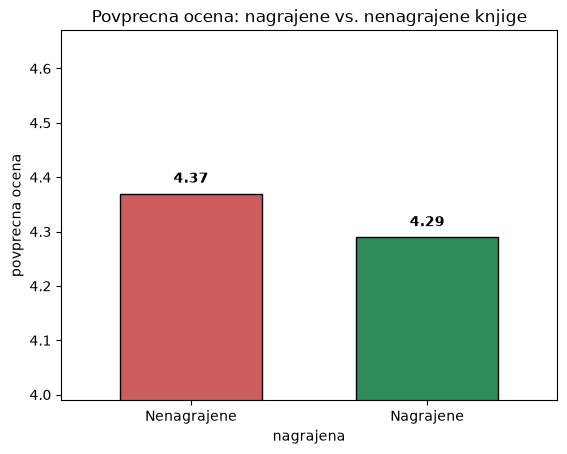

In [44]:
ax = primerjava_nagrad["mean"].plot.bar(
    color=["indianred", "seagreen"],
    edgecolor="black",
    width=0.6
)
ax.set_xticklabels(["Nenagrajene", "Nagrajene"], rotation=0)
ax.set_ylabel("povprecna ocena")
ax.set_title("Povprecna ocena: nagrajene vs. nenagrajene knjige")

# priblizamo y-os na relevantno obmocje, da je majhna razlika sploh vidna
spodnja_meja = primerjava_nagrad["mean"].min() - 0.3
zgornja_meja = primerjava_nagrad["mean"].max() + 0.3
ax.set_ylim(spodnja_meja, zgornja_meja)

# dodamo tocne vrednosti nad vsak stolpec
for i, vrednost in enumerate(primerjava_nagrad["mean"]):
    ax.text(i, vrednost + 0.02, f"{vrednost:.2f}", ha="center", fontweight="bold");

## Avtorji

Avtorji z največ knjigami v zbirki Mestne knjižnice Ljubljana.

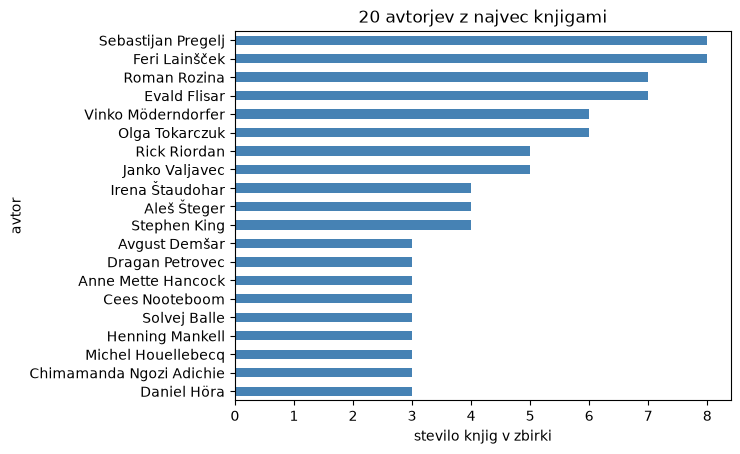

In [45]:
top20_avtorjev = KNJIGE.groupby("avtor").size().sort_values(ascending=False).head(20)

ax = top20_avtorjev.plot.barh(color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("stevilo knjig v zbirki")
ax.set_title("20 avtorjev z najvec knjigami");

Povprečna ocena po avtorju (samo avtorji z vsaj 3 ocenjenimi knjigami v zbirki):

In [46]:
ocena_po_avtorju = OCENJENE.groupby("avtor").agg(
    povprecna_ocena=("ocena", "mean"),
    stevilo_knjig=("naslov", "count")
)

zanesljivi_avtorji = ocena_po_avtorju[ocena_po_avtorju["stevilo_knjig"] >= 3]
zanesljivi_avtorji.sort_values("povprecna_ocena", ascending=False).round(2).head(15)

,povprecna_ocena,stevilo_knjig
avtor,,
Rick Riordan,5.00,5
Frank Herbert,5.00,3
J. K. Rowling,4.90,3
Henning Mankell,4.90,3
Chimamanda Ngozi Adichie,4.83,3
Roman Rozina,4.83,6
Manu Larcenet,4.83,3
Stephen King,4.77,3
Marko Sosič,4.70,3


## Korelacije

Razmerja med številom strani, oceno, časom branja in številom ocen. Vsaka pika predstavlja eno knjigo.

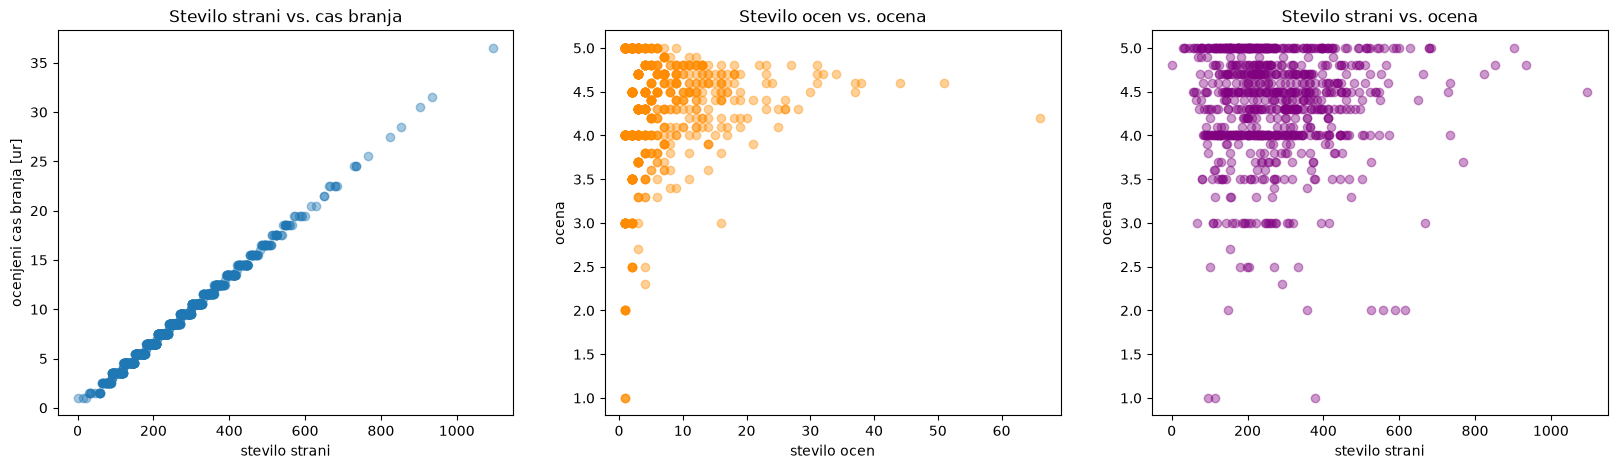

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(KNJIGE["stevilo_strani"], KNJIGE["cas_branja_ur"], alpha=0.4)
axes[0].set_xlabel("stevilo strani")
axes[0].set_ylabel("ocenjeni cas branja [ur]")
axes[0].set_title("Stevilo strani vs. cas branja")

axes[1].scatter(OCENJENE["stevilo_ocen"], OCENJENE["ocena"], alpha=0.4, color="darkorange")
axes[1].set_xlabel("stevilo ocen")
axes[1].set_ylabel("ocena")
axes[1].set_title("Stevilo ocen vs. ocena")

axes[2].scatter(OCENJENE["stevilo_strani"], OCENJENE["ocena"], alpha=0.4, color="purple")
axes[2].set_xlabel("stevilo strani")
axes[2].set_ylabel("ocena")
axes[2].set_title("Stevilo strani vs. ocena");

In [48]:
print("Korelacija stevilo_strani vs cas_branja_ur:", round(KNJIGE["stevilo_strani"].corr(KNJIGE["cas_branja_ur"]), 3))
print("Korelacija stevilo_ocen vs ocena:", round(OCENJENE["stevilo_ocen"].corr(OCENJENE["ocena"]), 3))
print("Korelacija stevilo_strani vs ocena:", round(OCENJENE["stevilo_strani"].corr(OCENJENE["ocena"]), 3))

Korelacija stevilo_strani vs cas_branja_ur: 0.998
Korelacija stevilo_ocen vs ocena: 0.094
Korelacija stevilo_strani vs ocena: 0.013
